In [30]:
import warnings
warnings.filterwarnings("ignore")

import logging
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
# Splitst de dataset in trainingsdata en testdata

from sklearn.compose import ColumnTransformer
# Laat je verschillende kolommen op verschillende manieren verwerken

from sklearn.pipeline import Pipeline
# Zet preprocessing en modeltraining in één vaste volgorde

from sklearn.preprocessing import OneHotEncoder, StandardScaler
# OneHotEncoder maakt van categorieën dummyvariabelen
# StandardScaler zet numerieke waarden op ongeveer dezelfde schaal

from sklearn.impute import SimpleImputer
# Vult ontbrekende waarden op

from sklearn.linear_model import SGDRegressor
# Model voor het voorspellen van numerieke uitkomsten

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# Metrics om te beoordelen hoe goed het model presteert

In [31]:
logger = logging.getLogger("ames_notebook")
logger.setLevel(logging.INFO)
# Maakt een logger aan die meldingen vanaf INFO-niveau laat zien

if not logger.handlers:
    handler = logging.StreamHandler()
    handler.setFormatter(logging.Formatter("%(levelname)s - %(message)s"))
    logger.addHandler(handler)
    # Voegt een handler toe die logberichten netjes in de console toont

logger.propagate = False
# Voorkomt dat berichten dubbel worden doorgestuurd

logger.info("Logger is gestart")
# Testbericht om te controleren of de logger werkt

INFO - Logger is gestart


In [32]:
bestand = "AmesHousing.xlsx"

df = pd.read_excel(bestand, sheet_name="AmesHousing")
data_dictionary = pd.read_excel(bestand, sheet_name="Data Dictionary")
# Leest twee tabbladen uit het Excel-bestand in als DataFrames

logger.info(f"Dataset ingeladen met shape: {df.shape}")
# Laat in de log zien hoeveel rijen en kolommen de dataset heeft

df.head()
# Toont de eerste 5 rijen van de dataset als controle

INFO - Dataset ingeladen met shape: (2930, 12)


,ID,SalePrice,Garage,Overall Qual,Gr Liv Area,Total Bsmt SF,Lot Area,Year Built,Full Bath,Bedroom AbvGr,Neighborhood,House Style
0,1,215000,yes,6,1656,1080.0,31770,1960,1,3,NAmes,1Story
1,2,105000,yes,5,896,882.0,11622,1961,1,2,NAmes,1Story
2,3,172000,yes,6,1329,1329.0,14267,1958,1,3,NAmes,1Story
3,4,244000,yes,7,2110,2110.0,11160,1968,2,3,NAmes,1Story
4,5,189900,yes,5,1629,928.0,13830,1997,2,3,Gilbert,2Story


In [33]:
data_dictionary.head(20)
# Toont de eerste 20 rijen van de data dictionary

,Variabele,Betekenis
0,ID,"Uniek nummer per huis, te vergelijken met een ..."
1,SalePrice,Verkoopprijs van het huis (in dollars: USD)
2,Garage,Geeft weer of het huis wel/geen garage bevat
3,Overall Qual,Algemene kwaliteit van materialen en afwerking...
4,Gr Liv Area,Woonoppervlak boven de grond (square feet)
5,Total Bsmt SF,Totale oppervlakte van de kelder
6,Lot Area,Grootte van het perceel (square feet)
7,Year Built,Bouwjaar van het huis
8,Full Bath,Aantal volledige badkamers
9,Bedroom AbvGr,Aantal slaapkamers boven de grond


In [34]:
df.columns.tolist()
# Geeft een lijst met alle kolomnamen uit de dataset

['ID',
 'SalePrice',
 'Garage',
 'Overall Qual',
 'Gr Liv Area',
 'Total Bsmt SF',
 'Lot Area',
 'Year Built',
 'Full Bath',
 'Bedroom AbvGr',
 'Neighborhood',
 'House Style']

In [35]:
target = "SalePrice"
features = ["Overall Qual", "Gr Liv Area", "Neighborhood"]
# Doelvariabele en gekozen invoer kenmerken voor het model

logger.info(f"Gekozen target: {target}")
logger.info(f"Gekozen features: {features}")
# Logt welke target en features gebruikt worden

INFO - Gekozen target: SalePrice
INFO - Gekozen features: ['Overall Qual', 'Gr Liv Area', 'Neighborhood']


In [36]:
data = df[features + [target]].copy()
# Maakt een nieuwe dataset met alleen de gekozen features en de target

data.head()
# Toont de eerste 5 rijen als controle

,Overall Qual,Gr Liv Area,Neighborhood,SalePrice
0,6,1656,NAmes,215000
1,5,896,NAmes,105000
2,6,1329,NAmes,172000
3,7,2110,NAmes,244000
4,5,1629,Gilbert,189900


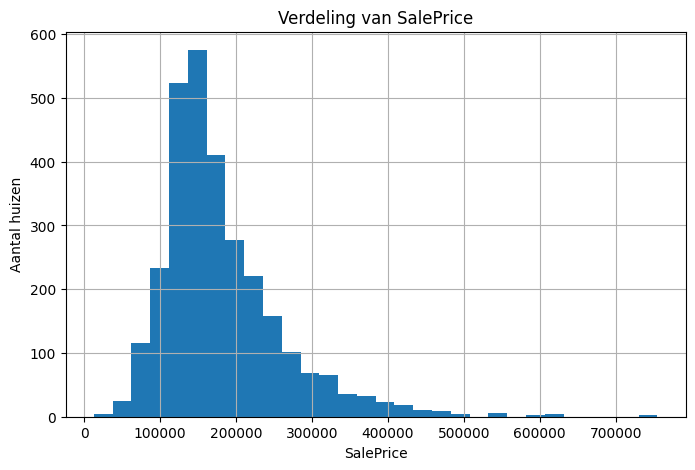

In [37]:
plt.figure(figsize=(8, 5))
plt.hist(data[target].dropna(), bins=30)
# Maakt een histogram van de target variabele om de verdeling te bekijken

plt.title("Verdeling van SalePrice")
plt.xlabel("SalePrice")
plt.ylabel("Aantal huizen")

plt.grid(True)
plt.show()
# Toont de grafiek

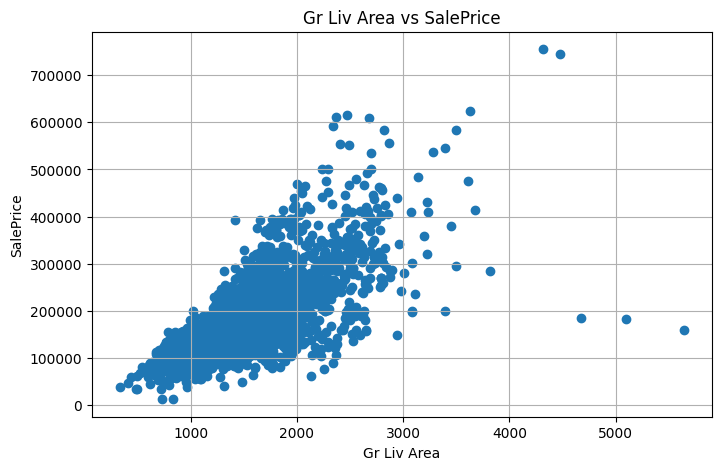

In [38]:
plt.figure(figsize=(8, 5))
plt.scatter(data["Gr Liv Area"], data[target])
# Maakt een spreidingsdiagram om het verband tussen woonoppervlakte en verkoopprijs te bekijken

plt.title("Gr Liv Area vs SalePrice")
plt.xlabel("Gr Liv Area")
plt.ylabel("SalePrice")

plt.grid(True)
plt.show()
# Toont de grafiek

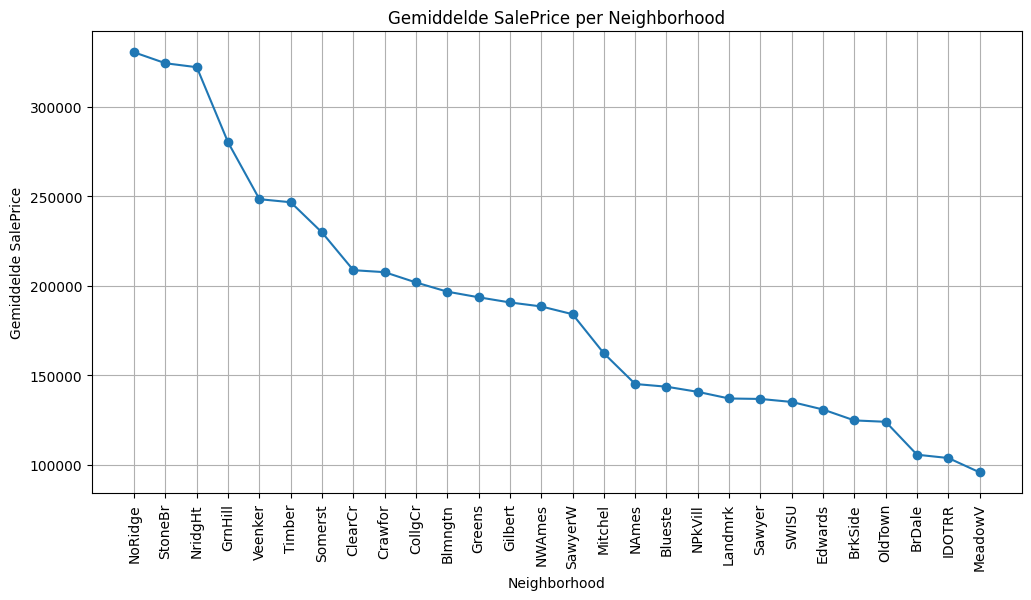

In [39]:
gemiddelde_prijs = data.groupby("Neighborhood")[target].mean().sort_values(ascending=False)
# Berekent de gemiddelde verkoopprijs per buurt en sorteert van hoog naar laag

plt.figure(figsize=(12, 6))
plt.plot(gemiddelde_prijs.index, gemiddelde_prijs.values, marker="o")
# Visualiseert de gemiddelde verkoopprijs per buurt

plt.title("Gemiddelde SalePrice per Neighborhood")
plt.xlabel("Neighborhood")
plt.ylabel("Gemiddelde SalePrice")
plt.xticks(rotation=90)

plt.grid(True)
plt.show()
# Toont de grafiek

In [40]:
data = data.dropna(subset=[target])
# Verwijdert rijen waarin de target ontbreekt

X = data[features]
y = data[target]
# Splitst de data in invoervariabelen (X) en doelvariabele (y)

logger.info(f"X shape: {X.shape}")
logger.info(f"y shape: {y.shape}")
# Laat zien hoeveel rijen en kolommen X en y hebben

INFO - X shape: (2930, 3)
INFO - y shape: (2930,)


In [41]:
help(SGDRegressor)
# Toont de ingebouwde documentatie van SGDRegressor

Help on class SGDRegressor in module sklearn.linear_model._stochastic_gradient:

class SGDRegressor(BaseSGDRegressor)
 |  SGDRegressor(
 |      loss='squared_error',
 |      *,
 |      penalty='l2',
 |      alpha=0.0001,
 |      l1_ratio=0.15,
 |      fit_intercept=True,
 |      max_iter=1000,
 |      tol=0.001,
 |      shuffle=True,
 |      verbose=0,
 |      epsilon=0.1,
 |      random_state=None,
 |      learning_rate='invscaling',
 |      eta0=0.01,
 |      power_t=0.25,
 |      early_stopping=False,
 |      validation_fraction=0.1,
 |      n_iter_no_change=5,
 |      warm_start=False,
 |      average=False
 |  )
 |
 |  Linear model fitted by minimizing a regularized empirical loss with SGD.
 |
 |  SGD stands for Stochastic Gradient Descent: the gradient of the loss is
 |  estimated each sample at a time and the model is updated along the way with
 |  a decreasing strength schedule (aka learning rate).
 |
 |  The regularizer is a penalty added to the loss function that shrinks mode

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=42
    # Zorgt dat steeds dezelfde rijen in train en test terechtkomen
)
# Splitst de data in trainingsdata en testdata

logger.info(f"X_train shape: {X_train.shape}")
logger.info(f"X_test shape: {X_test.shape}")
logger.info(f"y_train shape: {y_train.shape}")
logger.info(f"y_test shape: {y_test.shape}")
# Laat zien hoe groot elke dataset is na het splitsen

INFO - X_train shape: (2490, 3)
INFO - X_test shape: (440, 3)
INFO - y_train shape: (2490,)
INFO - y_test shape: (440,)


In [43]:
categorische_kolommen = X.select_dtypes(include=["object"]).columns.tolist()
# Zoekt kolommen met tekstwaarden en zet die in een lijst

numerieke_kolommen = [kolom for kolom in X.columns if kolom not in categorische_kolommen]
# Zet de overgebleven kolommen in de lijst met numerieke kolommen

logger.info(f"Categorische kolommen: {categorische_kolommen}")
logger.info(f"Numerieke kolommen: {numerieke_kolommen}")
# Laat zien welke kolommen als categorisch en numeriek zijn ingedeeld

INFO - Categorische kolommen: ['Neighborhood']
INFO - Numerieke kolommen: ['Overall Qual', 'Gr Liv Area']


In [44]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numerieke_kolommen
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorische_kolommen
        )
    ]
)
# Verwerkt numerieke en categorische kolommen elk op hun eigen manier

In [45]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", SGDRegressor(
        max_iter=1000,
        eta0=0.0001,
        learning_rate="constant",
        random_state=42
    ))
])
# Combineert de preprocessing en het regressiemodel in één pipeline

logger.info("Model aangemaakt")
# Geeft aan dat het model succesvol is opgesteld

INFO - Model aangemaakt


In [46]:
model.fit(X_train, y_train)
# Traint het model met de trainingsdata

logger.info("Model is getraind")
# Meldt dat het trainen is afgerond

INFO - Model is getraind


In [47]:
y_pred = model.predict(X_test)
# Laat het getrainde model voorspellingen maken op de testdata

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
# Berekent hoe goed de voorspellingen van het model zijn

pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R2"],
    "Waarde": [mae, mse, rmse, r2]
})
# Zet de evaluatiescores overzichtelijk in een tabel

,Metric,Waarde
0,MAE,2.512726e+04
1,MSE,1.504730e+09
2,RMSE,3.879085e+04
3,R2,8.041358e-01


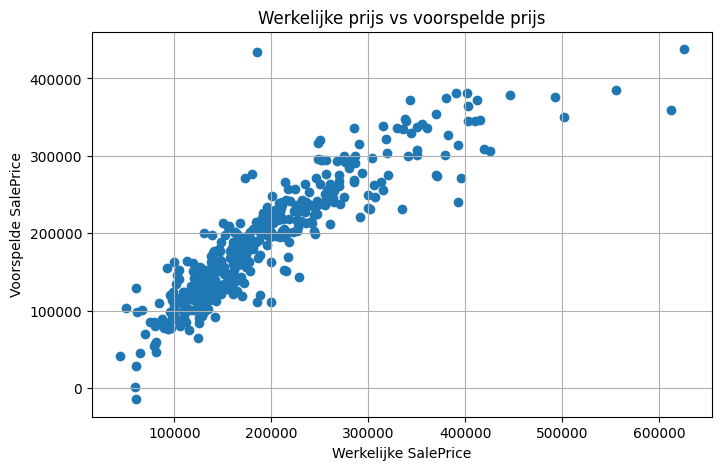

In [48]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred)
# Vergelijkt de werkelijke prijzen met de voorspelde prijzen in een scatterplot

plt.title("Werkelijke prijs vs voorspelde prijs")
plt.xlabel("Werkelijke SalePrice")
plt.ylabel("Voorspelde SalePrice")

plt.grid(True)
plt.show()
# Toont de grafiek

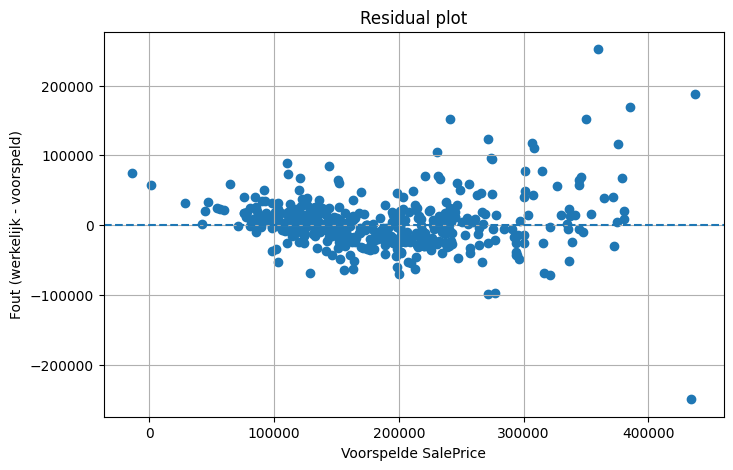

In [49]:
residuals = y_test.to_numpy() - y_pred
# Berekent per huis het verschil tussen de echte prijs en de voorspelde prijs

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals)
# Laat zien hoe groot de fouten zijn bij de voorspellingen

plt.axhline(y=0, linestyle="--")
# Tekent een lijn bij fout = 0 als referentie

plt.title("Residual plot")
plt.xlabel("Voorspelde SalePrice")
plt.ylabel("Fout (werkelijk - voorspeld)")

plt.grid(True)
plt.show()
# Toont de grafiek

In [50]:
def voer_experiment_uit(df, features, target, max_iter, eta0, learning_rate="constant", run_naam="Run"):
    # Functie die één compleet machine-learning experiment uitvoert

    data = df[features + [target]].copy()
    data = data.dropna(subset=[target])

    X = data[features]
    y = data[target]
    # Maakt de invoerdata (X) en doelvariabele (y)

    categorische_kolommen = X.select_dtypes(include=["object"]).columns.tolist()
    numerieke_kolommen = [kolom for kolom in X.columns if kolom not in categorische_kolommen]
    # Verdeelt de features in categorische en numerieke kolommen

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.15,
        random_state=42
    )
    # Splitst de data in train- en testdata

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler())
                ]),
                numerieke_kolommen
            ),
            (
                "cat",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore"))
                ]),
                categorische_kolommen
            )
        ]
    )
    # Bereidt numerieke en categorische kolommen elk op hun eigen manier voor

    model = Pipeline([
        ("preprocessor", preprocessor),
        ("regressor", SGDRegressor(
            max_iter=max_iter,
            eta0=eta0,
            learning_rate=learning_rate,
            random_state=42
        ))
    ])
    # Combineert preprocessing en model in één pipeline

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    # Traint het model en maakt voorspellingen op de testdata

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    # Berekent de prestaties van het model

    return {
        "Run": run_naam,
        "Features": ", ".join(features),
        "max_iter": max_iter,
        "eta0": eta0,
        "learning_rate": learning_rate,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2,
        "y_test": y_test.to_numpy(),
        "y_pred": y_pred
    }
    # Geeft de instellingen en resultaten van het experiment terug

In [51]:
experimenten = [
    {
        "features": ["Overall Qual", "Gr Liv Area", "Neighborhood"],
        "max_iter": 1000,
        "eta0": 0.0001,
        "learning_rate": "constant",
        "run_naam": "Initiële run"
    },
    {
        "features": ["Overall Qual", "Gr Liv Area", "Neighborhood", "Year Built"],
        "max_iter": 1500,
        "eta0": 0.0001,
        "learning_rate": "constant",
        "run_naam": "Experiment 1"
    },
    {
        "features": ["Overall Qual", "Gr Liv Area", "Neighborhood", "House Style", "Year Built"],
        "max_iter": 2000,
        "eta0": 0.0005,
        "learning_rate": "constant",
        "run_naam": "Experiment 2"
    },
    {
        "features": ["Overall Qual", "Gr Liv Area", "Neighborhood", "House Style", "Year Built", "Total Bsmt SF"],
        "max_iter": 3000,
        "eta0": 0.001,
        "learning_rate": "constant",
        "run_naam": "Experiment 3"
    }
]
# Bevat meerdere experimenten met verschillende instellingen voor het model

In [52]:
alle_runs = []
# Lege lijst om de resultaten van alle experimenten op te slaan

for exp in experimenten:
    run_resultaat = voer_experiment_uit(
        df=df,
        features=exp["features"],
        target=target,
        max_iter=exp["max_iter"],
        eta0=exp["eta0"],
        learning_rate=exp["learning_rate"],
        run_naam=exp["run_naam"]
    )
    alle_runs.append(run_resultaat)
    # Voert elk experiment uit en slaat het resultaat op

In [53]:
resultaten_df = pd.DataFrame([
    {
        "Run": run["Run"],
        "Features": run["Features"],
        "max_iter": run["max_iter"],
        "eta0": run["eta0"],
        "learning_rate": run["learning_rate"],
        "MAE": run["MAE"],
        "MSE": run["MSE"],
        "RMSE": run["RMSE"],
        "R2": run["R2"]
    }
    for run in alle_runs
])
# Zet de resultaten van alle experimenten om in één overzichtelijke tabel

resultaten_df
# Toont de tabel met alle resultaten

,Run,Features,max_iter,eta0,learning_rate,MAE,MSE,RMSE,R2
0,Initiële run,"Overall Qual, Gr Liv Area, Neighborhood",1000,0.0001,constant,25127.264988,1.504730e+09,38790.853076,0.804136
1,Experiment 1,"Overall Qual, Gr Liv Area, Neighborhood, Year ...",1500,0.0001,constant,24512.368682,1.457173e+09,38172.938592,0.810326
2,Experiment 2,"Overall Qual, Gr Liv Area, Neighborhood, House...",2000,0.0005,constant,22985.042287,1.330063e+09,36470.031062,0.826871
3,Experiment 3,"Overall Qual, Gr Liv Area, Neighborhood, House...",3000,0.0010,constant,22833.954725,1.271765e+09,35661.818111,0.834460


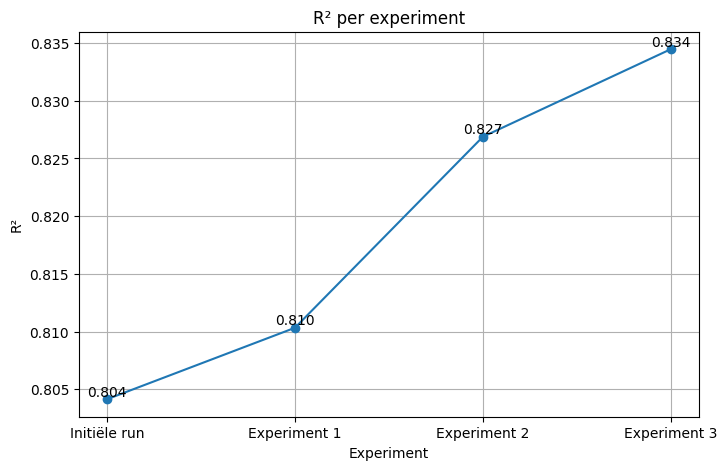

In [54]:
plt.figure(figsize=(8, 5))
plt.plot(resultaten_df["Run"], resultaten_df["R2"], marker="o")
# Laat de R²-score van elk experiment in een grafiek zien

for x, y in zip(resultaten_df["Run"], resultaten_df["R2"]):
    plt.text(x, y, f"{y:.3f}", ha="center", va="bottom")
# Zet de exacte R²-waarde bij elk punt

plt.title("R² per experiment")
plt.xlabel("Experiment")
plt.ylabel("R²")
plt.grid(True)
plt.show()
# Toont de grafiek

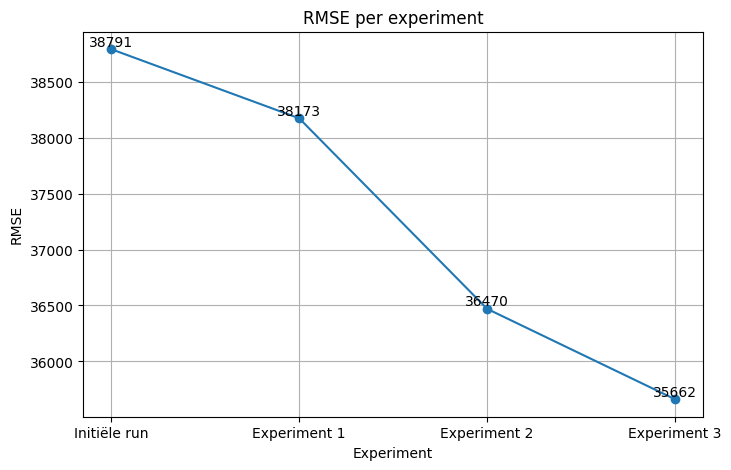

In [55]:
plt.figure(figsize=(8, 5))
plt.plot(resultaten_df["Run"], resultaten_df["RMSE"], marker="o")
# Laat de RMSE-score van elk experiment in een grafiek zien

for x, y in zip(resultaten_df["Run"], resultaten_df["RMSE"]):
    plt.text(x, y, f"{y:.0f}", ha="center", va="bottom")
# Zet de exacte RMSE-waarde bij elk punt

plt.title("RMSE per experiment")
plt.xlabel("Experiment")
plt.ylabel("RMSE")
plt.grid(True)
plt.show()
# Toont de grafiek

In [56]:
beste_run_naam = resultaten_df.sort_values(by="R2", ascending=False).iloc[0]["Run"]
# Zoekt het experiment met de hoogste R²-score en bewaart de naam daarvan

beste_run_data = next(run for run in alle_runs if run["Run"] == beste_run_naam)
# Haalt uit alle runs de bijbehorende gegevens van de beste run op

resultaten_df[resultaten_df["Run"] == beste_run_naam]
# Toont in de tabel alleen de resultaten van de beste run

,Run,Features,max_iter,eta0,learning_rate,MAE,MSE,RMSE,R2
3,Experiment 3,"Overall Qual, Gr Liv Area, Neighborhood, House...",3000,0.001,constant,22833.954725,1.271765e+09,35661.818111,0.83446


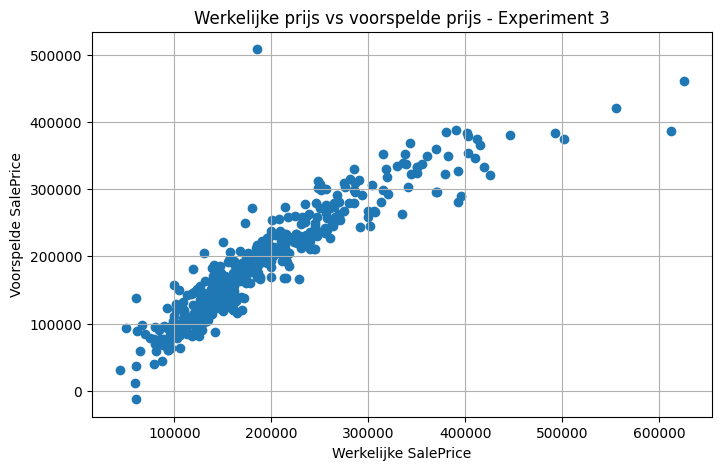

In [57]:
plt.figure(figsize=(8, 5))
plt.scatter(beste_run_data["y_test"], beste_run_data["y_pred"])
# Vergelijkt bij de beste run de echte prijzen met de voorspelde prijzen

plt.title(f"Werkelijke prijs vs voorspelde prijs - {beste_run_naam}")
plt.xlabel("Werkelijke SalePrice")
plt.ylabel("Voorspelde SalePrice")
plt.grid(True)
plt.show()
# Toont de grafiek

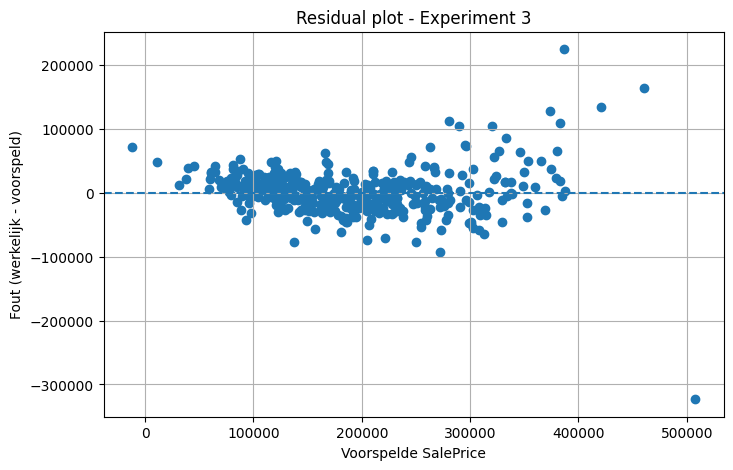

In [58]:
beste_residuals = beste_run_data["y_test"] - beste_run_data["y_pred"]
# Berekent de fouten van de beste run

plt.figure(figsize=(8, 5))
plt.scatter(beste_run_data["y_pred"], beste_residuals)
# Laat zien hoe groot de fouten zijn ten opzichte van de voorspelde prijzen

plt.axhline(y=0, linestyle="--")
# Tekent een referentielijn bij fout = 0

plt.title(f"Residual plot - {beste_run_naam}")
plt.xlabel("Voorspelde SalePrice")
plt.ylabel("Fout (werkelijk - voorspeld)")
plt.grid(True)
plt.show()
# Toont de grafiek